# Looka E-Commerce: End-to-End Data Analytics Project

## 1. Environment Setup & Library Import
Tahap ini bertujuan untuk mempersiapkan *environment* analisis, mengimpor *library* utama untuk manipulasi data (Pandas, Numpy) dan visualisasi (Matplotlib, Seaborn, Missingno).

In [ ]:
# Import library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

# Konfigurasi standar untuk tampilan visualisasi dan tabel pandas
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading
Memuat tabel-tabel operasional utama dari folder `raw`. Untuk efisiensi memori awal, kita akan memuat 4 tabel inti yang merepresentasikan transaksi dan entitas bisnis utama: `orders`, `order_items`, `products`, dan `users`.

In [ ]:
# Definisikan path untuk masing-masing dataset
path_orders = '../data/raw/thelook_ecommerce.orders.csv'
path_order_items = '../data/raw/thelook_ecommerce.order_items.csv'
path_products = '../data/raw/thelook_ecommerce.products.csv'
path_users = '../data/raw/thelook_ecommerce.users.csv'

# Load dataset ke dalam pandas DataFrame
df_orders = pd.read_csv(path_orders)
df_order_items = pd.read_csv(path_order_items)
df_products = pd.read_csv(path_products)
df_users = pd.read_csv(path_users)

# Verifikasi proses load data dengan menampilkan dimensi masing-masing tabel
print(f"Dimensi df_orders      : {df_orders.shape}")
print(f"Dimensi df_order_items : {df_order_items.shape}")
print(f"Dimensi df_products    : {df_products.shape}")
print(f"Dimensi df_users       : {df_users.shape}")

Dimensi df_orders      : (124923, 9)
Dimensi df_order_items : (180952, 11)
Dimensi df_products    : (29120, 9)
Dimensi df_users       : (100000, 15)


## 3. Initial Data Audit
Pemeriksaan awal struktur tabel `orders` dan `order_items` untuk melihat tipe data dan mendeteksi adanya *missing values* sebelum masuk ke tahap *Data Cleaning*.

In [ ]:
# Fungsi untuk membuat ringkasan informasi DataFrame
def summarize_dataframe(df):
    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Total Null': df.isnull().sum(),
        'Null Percentage (%)': (df.isnull().sum() / len(df)) * 100,
        'Unique Values': df.nunique()
    })
    return summary.round(2)

# Eksekusi fungsi untuk tabel orders
print("=== Ringkasan df_orders ===")
display(summarize_dataframe(df_orders))

# Eksekusi fungsi untuk tabel order_items
print("\n=== Ringkasan df_order_items ===")
display(summarize_dataframe(df_order_items))

=== Ringkasan df_orders ===


,Data Type,Total Null,Null Percentage (%),Unique Values
order_id,int64,0,0.00,124923
user_id,int64,0,0.00,79894
status,str,0,0.00,5
gender,str,0,0.00,2
created_at,str,0,0.00,114255
returned_at,str,112353,89.94,12487
shipped_at,str,43671,34.96,77939
delivered_at,str,81325,65.10,42606
num_of_item,int64,0,0.00,4



=== Ringkasan df_order_items ===


,Data Type,Total Null,Null Percentage (%),Unique Values
id,int64,0,0.00,180952
order_id,int64,0,0.00,124923
user_id,int64,0,0.00,79893
product_id,int64,0,0.00,29054
inventory_item_id,int64,0,0.00,180952
status,str,0,0.00,5
created_at,str,0,0.00,180607
shipped_at,str,63074,34.86,77939
delivered_at,str,117755,65.08,42606
returned_at,str,162765,89.95,12487


## 4. Data Cleaning
Proses pembersihan data meliputi perbaikan tipe data (casting), penanganan *missing values* berdasarkan aturan bisnis, dan ekstraksi informasi waktu (*feature engineering*).

### 4.1 Perbaikan Tipe Data Tanggal (Datetime Casting)
Mengonversi kolom waktu yang sebelumnya bertipe *string* menjadi objek *datetime* agar dapat dilakukan operasi temporal.

In [ ]:
# Membuat salinan data untuk proses cleaning
orders_clean = df_orders.copy()
order_items_clean = df_order_items.copy()
products_clean = df_products.copy()

# Mendefinisikan kolom mana saja yang merepresentasikan tanggal/waktu
time_cols_orders = ['created_at', 'returned_at', 'shipped_at', 'delivered_at']

# Iterasi untuk mengubah tipe data menggunakan pd.to_datetime dengan format UTC
for col in time_cols_orders:
    # parameter errors='coerce' akan mengubah format salah menjadi NaT (Not a Time)
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors='coerce').dt.tz_convert(None)
    order_items_clean[col] = pd.to_datetime(order_items_clean[col], errors='coerce').dt.tz_convert(None)

print("Tipe data kolom waktu setelah dikonversi (orders_clean):")
print(orders_clean[time_cols_orders].dtypes)

Tipe data kolom waktu setelah dikonversi (orders_clean):
created_at      datetime64[us]
returned_at     datetime64[us]
shipped_at      datetime64[us]
delivered_at    datetime64[us]
dtype: object


### 4.2 Handling Missing Values & Logika Bisnis
Kolom seperti `shipped_at`, `delivered_at`, dan `returned_at` memiliki persentase nilai kosong (*null*) yang tinggi. Hal ini wajar karena tidak semua pesanan selesai atau dikembalikan. Oleh karena itu, kita tidak akan menghapusnya (drop) atau mengisinya dengan nilai asal (impute), melainkan membiarkannya sebagai `NaT` (Not a Time) yang merepresentasikan kejadian bisnis yang belum atau tidak terjadi.

In [ ]:
# Ekstraksi komponen waktu dari kolom created_at
orders_clean['order_year'] = orders_clean['created_at'].dt.year
orders_clean['order_month'] = orders_clean['created_at'].dt.month
orders_clean['order_day'] = orders_clean['created_at'].dt.day_name()
orders_clean['order_hour'] = orders_clean['created_at'].dt.hour
orders_clean['order_year_month'] = orders_clean['created_at'].dt.to_period('M').astype(str)

# Menghitung durasi waktu pengiriman dalam hitungan jam
# Rumus: Waktu barang sampai (delivered) - Waktu pesanan dibuat (created)
orders_clean['lead_time_hours'] = (orders_clean['delivered_at'] - orders_clean['created_at']).dt.total_seconds() / 3600

# Menampilkan hasil feature engineering
display(orders_clean[['created_at', 'order_year_month', 'order_day', 'status', 'lead_time_hours']].head())

,created_at,order_year_month,order_day,status,lead_time_hours
0,2019-06-04 10:10:00,2019-06,Tuesday,Returned,101.750000
1,2022-05-23 14:42:00,2022-05,Monday,Processing,NaN
2,2020-06-20 15:09:00,2020-06,Saturday,Complete,98.316667
3,2021-08-23 15:09:00,2021-08,Monday,Complete,71.616667
4,2021-07-01 15:09:00,2021-07,Thursday,Shipped,NaN


### 4.4 Merging Tables (Creating Analytical Base Table)
Menggabungkan tabel `orders`, `order_items`, dan `products` menjadi satu tabel denormalisasi (Master Table). 
Catatan: Grain data (tingkat kedetailan) pada tabel master ini akan berubah dari "per pesanan" menjadi "per barang dalam pesanan" (Order Line Item).

In [ ]:
# Memilih kolom spesifik dari order_items untuk menghindari duplikasi kolom (seperti created_at_x, created_at_y)
order_items_subset = order_items_clean[['order_id', 'product_id', 'sale_price']]

# Join Tahap 1: Menggabungkan transaksi pesanan dengan rincian harganya (Left Join)
master_df = pd.merge(orders_clean, order_items_subset, on='order_id', how='left')

# Menyesuaikan nama primary key di tabel products agar sama dengan foreign key di master_df
products_subset = products_clean[['id', 'category', 'department', 'brand', 'cost', 'retail_price']].copy()
products_subset.rename(columns={'id': 'product_id'}, inplace=True)

# Join Tahap 2: Menggabungkan data pesanan dengan master data produk (Left Join)
master_df = pd.merge(master_df, products_subset, on='product_id', how='left')

# Memverifikasi lonjakan jumlah baris (karena 1 pesanan bisa memiliki > 1 barang)
print(f"Dimensi df_orders awal  : {orders_clean.shape}")
print(f"Dimensi df_master akhir : {master_df.shape}")

Dimensi df_orders awal  : (124923, 15)
Dimensi df_master akhir : (180952, 22)


### 4.5 Profitability Feature Engineering
Menghitung metrik finansial krusial untuk menjawab pertanyaan bisnis terkait keuntungan perusahaan, yaitu `gross_profit` (Laba Kotor).

In [ ]:
# Menghitung keuntungan kotor per barang (Harga Jual Aktual dikurangi Harga Modal/Cost)
master_df['gross_profit'] = master_df['sale_price'] - master_df['cost']

# Audit final dari tabel master yang sudah siap dianalisis
print("=== INFO METADATA MASTER DATAFRAME ===")
master_df.info()

# Menampilkan cuplikan data yang berfokus pada sisi finansial
display(master_df[['order_id', 'status', 'category', 'department', 'sale_price', 'cost', 'gross_profit']].head())

=== INFO METADATA MASTER DATAFRAME ===
<class 'pandas.DataFrame'>
RangeIndex: 180952 entries, 0 to 180951
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          180952 non-null  int64         
 1   user_id           180952 non-null  int64         
 2   status            180952 non-null  str           
 3   gender            180952 non-null  str           
 4   created_at        176500 non-null  datetime64[us]
 5   returned_at       17773 non-null   datetime64[us]
 6   shipped_at        115041 non-null  datetime64[us]
 7   delivered_at      61730 non-null   datetime64[us]
 8   num_of_item       180952 non-null  int64         
 9   order_year        176500 non-null  float64       
 10  order_month       176500 non-null  float64       
 11  order_day         176500 non-null  str           
 12  order_hour        176500 non-null  float64       
 13  order_year_month  176500 non-nu

,order_id,status,category,department,sale_price,cost,gross_profit
0,1,Returned,Sleep & Lounge,Men,9.000000,3.573000,5.427000
1,1,Returned,Pants,Men,54.990002,23.150791,31.839211
2,2,Processing,Maternity,Women,58.990002,26.840451,32.149551
3,3,Complete,Tops & Tees,Men,25.000000,13.400000,11.600000
4,3,Complete,Shorts,Men,28.500000,14.221500,14.278500


## 5. Exploratory Data Analysis (EDA)
Tahap ini bertujuan untuk mengekstraksi *insight* bisnis melalui visualisasi data. Kita akan berfokus pada analisis *Revenue Leakage* (kebocoran pendapatan) dan performa profitabilitas produk.

### 5.1 Analisis Status Pesanan & Revenue Leakage (Menjawab Q2)
Mengukur berapa banyak potensi pendapatan kotor (GMV) yang hilang akibat pesanan yang dibatalkan (*Cancelled*) atau dikembalikan (*Returned*).

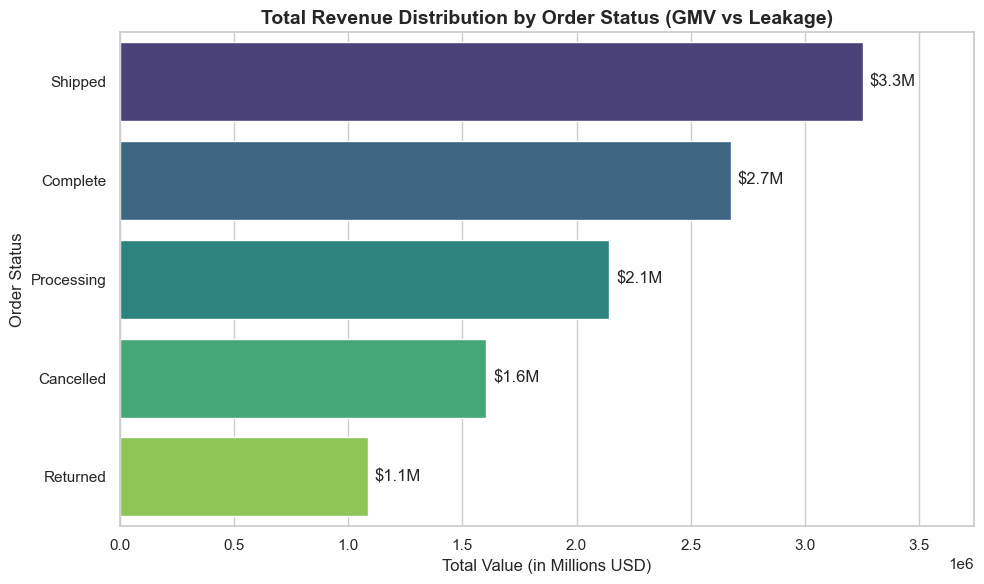

Total Gross Merchandise Value (GMV): $10,758,880.13
Total Revenue Leakage (Lost to Cancel/Return): $2,691,241.60
Revenue Leakage Percentage: 25.01%


In [ ]:
# Menghitung total nilai penjualan (GMV) berdasarkan status pesanan
revenue_by_status = master_df.groupby('status')['sale_price'].sum().reset_index()
revenue_by_status = revenue_by_status.sort_values(by='sale_price', ascending=False)

# Membuat visualisasi Bar Chart menggunakan Seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='sale_price', y='status', data=revenue_by_status, palette='viridis')

# Menambahkan label angka (dalam format Jutaan USD) pada bar chart
for p in ax.patches:
    ax.annotate(f'${p.get_width()/1e6:.1f}M', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.title('Total Revenue Distribution by Order Status (GMV vs Leakage)', fontsize=14, fontweight='bold')
plt.xlabel('Total Value (in Millions USD)', fontsize=12)
plt.ylabel('Order Status', fontsize=12)
plt.xlim(0, revenue_by_status['sale_price'].max() * 1.15) # Memberi ruang untuk label teks
plt.tight_layout()
plt.show()

# Kalkulasi persentase kebocoran (Leakage = Cancelled + Returned)
total_gmv = revenue_by_status['sale_price'].sum()
leakage_df = revenue_by_status[revenue_by_status['status'].isin(['Cancelled', 'Returned'])]
total_leakage = leakage_df['sale_price'].sum()

print(f"Total Gross Merchandise Value (GMV): ${total_gmv:,.2f}")
print(f"Total Revenue Leakage (Lost to Cancel/Return): ${total_leakage:,.2f}")
print(f"Revenue Leakage Percentage: {(total_leakage/total_gmv)*100:.2f}%")

### 5.2 Top Kategori Produk Berdasarkan Keuntungan (Menjawab Q3)
Mengidentifikasi 10 kategori produk teratas yang menyumbang Laba Kotor (*Gross Profit*) terbesar untuk perusahaan. Analisis ini difilter hanya untuk pesanan yang berhasil (Complete/Shipped).

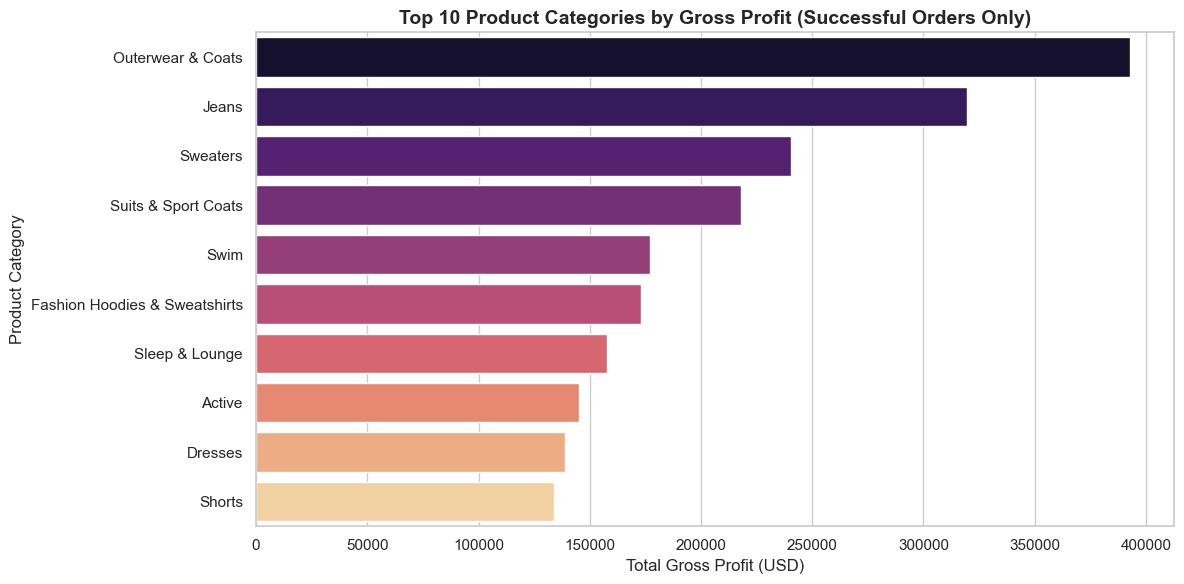

In [ ]:
# Filter hanya untuk transaksi yang menghasilkan uang riil (Complete & Shipped)
successful_orders = master_df[master_df['status'].isin(['Complete', 'Shipped'])]

# Agregasi Laba Kotor per Kategori
profit_by_category = successful_orders.groupby('category')['gross_profit'].sum().reset_index()
top_10_categories = profit_by_category.sort_values(by='gross_profit', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='gross_profit', y='category', data=top_10_categories, palette='magma')

plt.title('Top 10 Product Categories by Gross Profit (Successful Orders Only)', fontsize=14, fontweight='bold')
plt.xlabel('Total Gross Profit (USD)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 Analisis Tingkat Pengembalian (Return Rate) Berdasarkan Kategori (Menjawab Q4)
Kategori dengan profit tinggi belum tentu efisien jika memiliki tingkat pengembalian (*Return Rate*) yang juga tinggi. Kita perlu mendeteksi kategori mana yang kualitas barang dari *supplier*-nya bermasalah.

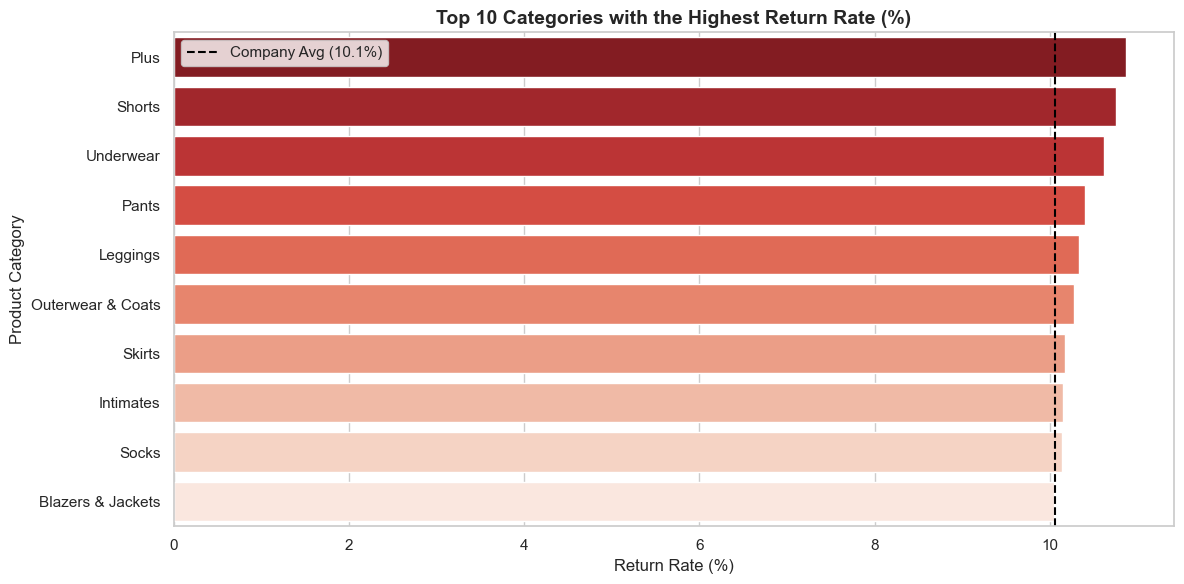

In [ ]:
# Menghitung total barang terjual vs total barang di-retur per kategori
category_stats = master_df.groupby('category').agg(
    total_items=('order_id', 'count'),
    returned_items=('status', lambda x: (x == 'Returned').sum())
).reset_index()

# Menghitung Return Rate %
category_stats['return_rate_pct'] = (category_stats['returned_items'] / category_stats['total_items']) * 100

# Filter kategori yang penjualannya cukup signifikan (>1000 item) agar datanya valid secara statistik
valid_categories = category_stats[category_stats['total_items'] > 1000]
worst_return_categories = valid_categories.sort_values(by='return_rate_pct', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='return_rate_pct', y='category', data=worst_return_categories, palette='Reds_r')

plt.title('Top 10 Categories with the Highest Return Rate (%)', fontsize=14, fontweight='bold')
plt.xlabel('Return Rate (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Menambahkan garis rata-rata return rate perusahaan sebagai benchmark
avg_return_rate = (master_df['status'] == 'Returned').mean() * 100
plt.axvline(avg_return_rate, color='black', linestyle='--', label=f'Company Avg ({avg_return_rate:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Analisis Keterlambatan Pengiriman (Menjawab Q5)
Menganalisis rata-rata waktu yang dibutuhkan untuk mengirim pesanan kepada pelanggan (*Lead Time* dalam satuan hari), dan membandingkan apakah pelanggan pria atau wanita yang mengalami waktu tunggu paling lama.

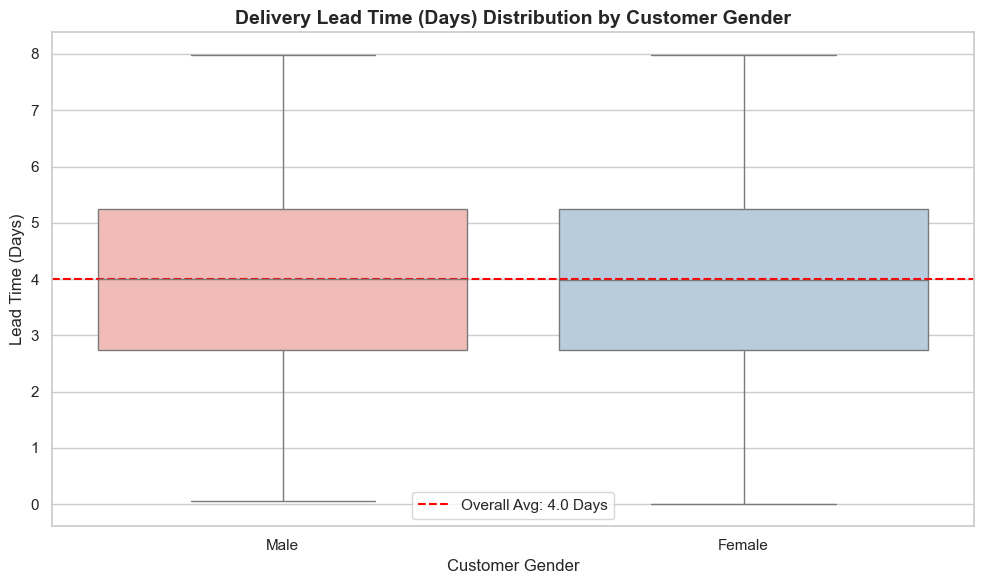

In [ ]:
# Menghitung Lead Time dalam satuan hari (dari kolom yang sebelumnya menggunakan jam)
master_df['lead_time_days'] = master_df['lead_time_hours'] / 24

# Memfilter data hanya untuk barang yang sukses dikirim
delivered_orders = master_df[master_df['status'] == 'Complete']

# Visualisasi distribusi waktu pengiriman (Lead Time) menggunakan Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='lead_time_days', data=delivered_orders, palette='Pastel1')

plt.title('Delivery Lead Time (Days) Distribution by Customer Gender', fontsize=14, fontweight='bold')
plt.xlabel('Customer Gender', fontsize=12)
plt.ylabel('Lead Time (Days)', fontsize=12)

# Hitung dan tampilkan rata-rata lead time keseluruhan
avg_lead_time = delivered_orders['lead_time_days'].mean()
plt.axhline(avg_lead_time, color='red', linestyle='--', label=f'Overall Avg: {avg_lead_time:.1f} Days')
plt.legend()
plt.tight_layout()
plt.show()

### 5.5 Segmentasi Pelanggan Berdasarkan Negara (Menjawab Q8)
Mengidentifikasi dari negara mana pelanggan paling berharga berasal (berdasarkan total *Gross Profit*). Hal ini memerlukan penggabungan (*Join*) tabel utama kita dengan tabel `users` untuk mendapatkan data geografi.

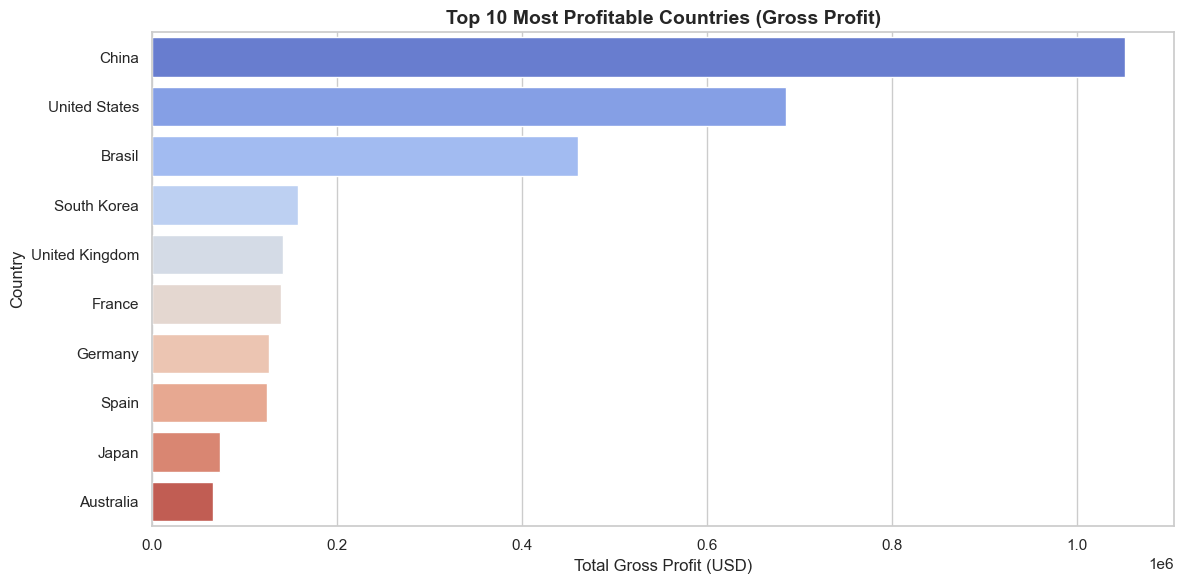

In [ ]:
# Memilih kolom geografi dari tabel users
users_subset = df_users[['id', 'country', 'city']].copy()
users_subset.rename(columns={'id': 'user_id'}, inplace=True)

# Melakukan JOIN antara tabel master dengan tabel users
master_geo_df = pd.merge(master_df, users_subset, on='user_id', how='left')

# Mengagregasi profit berdasarkan negara pembeli (hanya order yang sukses)
successful_geo_orders = master_geo_df[master_geo_df['status'].isin(['Complete', 'Shipped'])]
profit_by_country = successful_geo_orders.groupby('country')['gross_profit'].sum().reset_index()
profit_by_country = profit_by_country.sort_values(by='gross_profit', ascending=False).head(10)

# Visualisasi Bar Chart Profit per Negara
plt.figure(figsize=(12, 6))
sns.barplot(x='gross_profit', y='country', data=profit_by_country, palette='coolwarm')

plt.title('Top 10 Most Profitable Countries (Gross Profit)', fontsize=14, fontweight='bold')
plt.xlabel('Total Gross Profit (USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Mengekspor master DataFrame ke folder 'processed' agar siap digunakan di Power BI
# Kita tidak mengekspor indeks bawaan pandas agar data tetap bersih
export_path = '../data/processed/looka_master_data_clean.csv'

# Mengonversi kembali kolom datetime menjadi string (ISO format) agar mudah dibaca oleh Power BI
time_cols = ['created_at', 'returned_at', 'shipped_at', 'delivered_at']
for col in time_cols:
    master_geo_df[col] = master_geo_df[col].dt.strftime('%Y-%m-%d %H:%M:%S')

master_geo_df.to_csv(export_path, index=False)

print(f"Data berhasil diekspor ke: {export_path}")
print(f"Total baris yang diekspor: {len(master_geo_df)}")

Data berhasil diekspor ke: ../data/processed/looka_master_data_clean.csv
Total baris yang diekspor: 180952
